<a href="https://colab.research.google.com/github/jothigup/weather-prediction-RDU/blob/daniel-linear-regression/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 1. IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# RDU actual observations
actual = pd.read_csv(
    'RDU_ACTUAL_HISTORICAL.csv'
)

# Open-Meteo historical forecasts
# Real column names are on row 3 of the CSV
forecast_hist = pd.read_csv(
    'FORECAST_HISTORICAL.csv',
    skiprows=3
)

# Open-Meteo future forecast
# Real column names are on row 3 of the CSV
forecast_future = pd.read_csv(
    'FORECAST_FUTURE.csv',
    skiprows=3
)

In [6]:
print("ACTUAL")
print(actual.shape)
print(actual.head())
print(actual.dtypes)

print("\nHISTORICAL FORECAST")
print(forecast_hist.shape)
print(forecast_hist.head())
print(forecast_hist.dtypes)

print("\nFUTURE FORECAST")
print(forecast_future.shape)
print(forecast_future.head())
print(forecast_future.dtypes)

ACTUAL
(86092, 30)
  station             valid   tmpf   dwpf   relh   drct   sknt  p01i   alti  \
0     RDU  2018-01-01 00:51  23.00  -0.90  34.52  30.00   9.00  0.00  30.38   
1     RDU  2018-01-01 01:51  21.90   0.00  37.72  40.00  11.00  0.00  30.40   
2     RDU  2018-01-01 02:51  19.90   0.00  41.06  40.00   9.00  0.00  30.41   
3     RDU  2018-01-01 03:51  18.00   1.00  46.68  50.00   7.00  0.00  30.43   
4     RDU  2018-01-01 04:51  16.00   1.00  50.90  60.00   8.00  0.00  30.43   

      mslp  ... wxcodes ice_accretion_1hr ice_accretion_3hr ice_accretion_6hr  \
0  1029.30  ...       M                 M                 M                 M   
1  1030.00  ...       M                 M                 M                 M   
2  1030.40  ...       M                 M                 M                 M   
3  1031.10  ...       M                 M                 M                 M   
4  1031.20  ...       M                 M                 M                 M   

  peak_wind_gust pe

In [7]:
# Rename actual timestamp column
actual = actual.rename(columns={'valid': 'time'})

# Convert timestamps to datetime
actual['time'] = pd.to_datetime(actual['time'])
forecast_hist['time'] = pd.to_datetime(forecast_hist['time'])
forecast_future['time'] = pd.to_datetime(forecast_future['time'])

In [8]:
print("Actual date range:")
print(actual['time'].min(), actual['time'].max())

print("\nHistorical forecast date range:")
print(forecast_hist['time'].min(), forecast_hist['time'].max())

print("\nFuture forecast date range:")
print(forecast_future['time'].min(), forecast_future['time'].max())

print("\nDuplicate actual hours:")
print(actual['time'].duplicated().sum())

print("\nDuplicate forecast hours:")
print(forecast_hist['time'].duplicated().sum())

Actual date range:
2018-01-01 00:51:00 2026-09-25 23:51:00

Historical forecast date range:
2024-01-01 00:00:00 2026-09-16 23:00:00

Future forecast date range:
2026-09-16 14:00:00 2026-10-02 13:00:00

Duplicate actual hours:
10

Duplicate forecast hours:
0


In [9]:
# ============================================================
# 4. CLEAN AND ALIGN ACTUAL TEMPERATURE
# ============================================================

# Convert actual temperature to numeric
# "M" and other non-numeric values become NaN
actual['tmpf'] = pd.to_numeric(actual['tmpf'], errors='coerce')

# Remove observations with no actual temperature
actual = actual.dropna(subset=['tmpf'])

# Align RDU observations to nearest hour
actual['time'] = actual['time'].dt.round('h')

# If multiple observations fall in the same hour,
# use their mean temperature
actual_hourly = (
    actual.groupby('time', as_index=False)['tmpf']
    .mean()
)

actual_hourly = actual_hourly.rename(
    columns={'tmpf': 'actual_temp'}
)

print(actual_hourly.head())
print(actual_hourly.shape)
print("Duplicate hours:", actual_hourly['time'].duplicated().sum())

                 time  actual_temp
0 2018-01-01 01:00:00         23.0
1 2018-01-01 02:00:00         21.9
2 2018-01-01 03:00:00         19.9
3 2018-01-01 04:00:00         18.0
4 2018-01-01 05:00:00         16.0
(76445, 2)
Duplicate hours: 0


In [10]:
# ============================================================
# 5. MERGE HISTORICAL FORECASTS WITH ACTUAL TEMPERATURE
# ============================================================

df = pd.merge(
    forecast_hist,
    actual_hourly,
    on='time',
    how='inner'
)

# Sort chronologically
df = df.sort_values('time').reset_index(drop=True)

print(df.shape)
print(df.head())

(23699, 40)
                 time  temperature_2m_previous_day1 (°F)  \
0 2024-01-01 00:00:00                                NaN   
1 2024-01-01 01:00:00                                NaN   
2 2024-01-01 02:00:00                                NaN   
3 2024-01-01 03:00:00                                NaN   
4 2024-01-01 04:00:00                                NaN   

   temperature_2m_previous_day2 (°F)  temperature_2m_previous_day3 (°F)  \
0                                NaN                                NaN   
1                                NaN                                NaN   
2                                NaN                                NaN   
3                                NaN                                NaN   
4                                NaN                                NaN   

   temperature_2m_previous_day4 (°F)  temperature_2m_previous_day5 (°F)  \
0                                NaN                                NaN   
1                         

In [11]:
print("Merged date range:")
print(df['time'].min(), "to", df['time'].max())

print("\nNumber of rows:")
print(len(df))

print("\nDuplicate hours:")
print(df['time'].duplicated().sum())

print("\nMissing values:")
print(df.isna().sum())

Merged date range:
2024-01-01 00:00:00 to 2026-09-16 23:00:00

Number of rows:
23699

Duplicate hours:
0

Missing values:
time                                        0
temperature_2m_previous_day1 (°F)         439
temperature_2m_previous_day2 (°F)         463
temperature_2m_previous_day3 (°F)         487
temperature_2m_previous_day4 (°F)         511
temperature_2m_previous_day5 (°F)         535
relative_humidity_2m_previous_day1 (%)    439
dew_point_2m_previous_day1 (°F)           439
precipitation_previous_day1 (inch)        439
pressure_msl_previous_day1 (hPa)          439
cloud_cover_previous_day1 (%)             439
wind_speed_10m_previous_day1 (mp/h)       439
wind_direction_10m_previous_day1 (°)      439
wind_direction_10m_previous_day2 (°)      463
wind_speed_10m_previous_day2 (mp/h)       463
cloud_cover_previous_day2 (%)             463
cloud_cover_previous_day3 (%)             487
wind_speed_10m_previous_day3 (mp/h)       487
wind_direction_10m_previous_day3 (°)      487
clou

In [12]:
# ============================================================
# 6. SIMPLE LINEAR REGRESSION DATASET
# ============================================================

lr_df = df[
    [
        'time',
        'temperature_2m_previous_day1 (°F)',
        'actual_temp'
    ]
].copy()

lr_df = lr_df.dropna()

lr_df = lr_df.rename(
    columns={
        'temperature_2m_previous_day1 (°F)': 'forecast_temp'
    }
)

print(lr_df.shape)
print(lr_df.head())

(23260, 3)
                   time  forecast_temp  actual_temp
439 2024-01-19 08:00:00           35.5         41.0
440 2024-01-19 09:00:00           33.7         45.0
441 2024-01-19 10:00:00           37.2         46.0
442 2024-01-19 11:00:00           39.2         50.0
443 2024-01-19 12:00:00           44.6         52.0


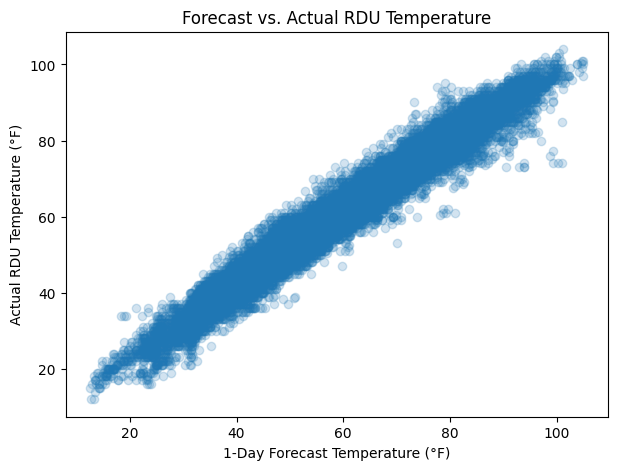

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(
    lr_df['forecast_temp'],
    lr_df['actual_temp'],
    alpha=0.2
)

plt.xlabel('1-Day Forecast Temperature (°F)')
plt.ylabel('Actual RDU Temperature (°F)')
plt.title('Forecast vs. Actual RDU Temperature')

plt.show()

In [14]:
# ============================================================
# 7. CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

X = lr_df[['forecast_temp']]
y = lr_df['actual_temp']

split = int(len(lr_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTrain period:")
print(lr_df['time'].iloc[0], "to", lr_df['time'].iloc[split - 1])

print("\nTest period:")
print(lr_df['time'].iloc[split], "to", lr_df['time'].iloc[-1])

Training: (18608, 1)
Testing: (4652, 1)

Train period:
2024-01-19 08:00:00 to 2026-03-06 17:00:00

Test period:
2026-03-06 18:00:00 to 2026-09-16 23:00:00


In [15]:
# ============================================================
# 8. TRAIN LINEAR REGRESSION
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 3.5596985232345943
Coefficient: 0.9692428772909951


In [16]:
# ============================================================
# 9. EVALUATE LINEAR REGRESSION
# ============================================================

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train RMSE: 3.3083265241425455
Test RMSE: 3.4729596961216442
Train R²: 0.9628721131969428
Test R²: 0.9273585815853961


In [17]:
# ============================================================
# 10. COMPARE AGAINST RAW FORECAST BASELINE
# ============================================================

raw_forecast_preds = X_test['forecast_temp']

raw_rmse = np.sqrt(
    mean_squared_error(y_test, raw_forecast_preds)
)

raw_r2 = r2_score(
    y_test,
    raw_forecast_preds
)

print("Raw GFS RMSE:", raw_rmse)
print("Linear Regression RMSE:", test_rmse)

print("\nRaw GFS R²:", raw_r2)
print("Linear Regression R²:", test_r2)

Raw GFS RMSE: 3.2063240100165125
Linear Regression RMSE: 3.4729596961216442

Raw GFS R²: 0.9380844630740693
Linear Regression R²: 0.9273585815853961


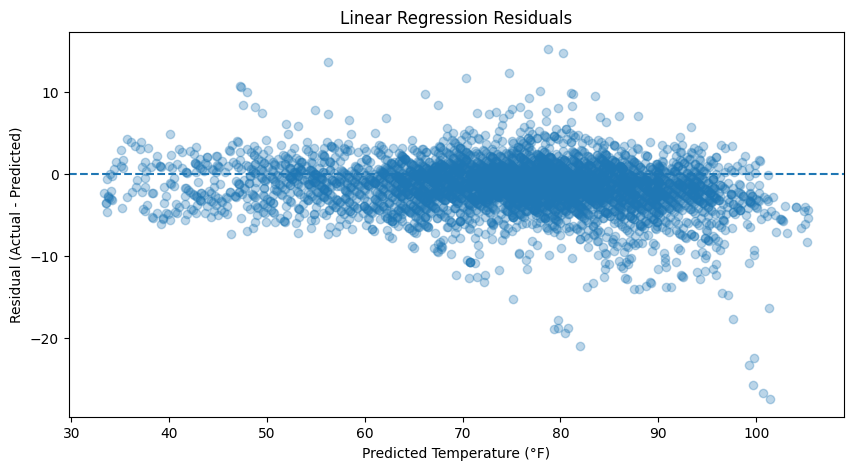

In [18]:
# ============================================================
# 11. RESIDUAL ANALYSIS
# ============================================================

results = lr_df.iloc[split:].copy()

results['prediction'] = test_preds
results['residual'] = y_test.values - test_preds

plt.figure(figsize=(10, 5))

plt.scatter(
    results['prediction'],
    results['residual'],
    alpha=0.3
)

plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Temperature (°F)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Linear Regression Residuals')

plt.show()

In [19]:
features = [
    'temperature_2m_previous_day1 (°F)',
    'relative_humidity_2m_previous_day1 (%)',
    'dew_point_2m_previous_day1 (°F)',
    'precipitation_previous_day1 (inch)',
    'pressure_msl_previous_day1 (hPa)',
    'cloud_cover_previous_day1 (%)',
    'wind_speed_10m_previous_day1 (mp/h)'
]

In [20]:
# ============================================================
# 12. MULTIPLE LINEAR REGRESSION
# ============================================================

mlr_df = df[['time', 'actual_temp'] + features].dropna().copy()

X = mlr_df[features]
y = mlr_df['actual_temp']

# Chronological split
split = int(len(mlr_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Train
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predict
train_preds = mlr.predict(X_train)
test_preds = mlr.predict(X_test)

# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train RMSE: 3.2319550058984285
Test RMSE: 3.3944451164865574
Train R²: 0.9645664953373875
Test R²: 0.9306059217744838


In [21]:
# ============================================================
# 13. ADD CYCLICAL TIME FEATURES
# ============================================================

mlr_df['hour'] = mlr_df['time'].dt.hour
mlr_df['day_of_year'] = mlr_df['time'].dt.dayofyear

# Hour of day: 24-hour cycle
mlr_df['hour_sin'] = np.sin(2 * np.pi * mlr_df['hour'] / 24)
mlr_df['hour_cos'] = np.cos(2 * np.pi * mlr_df['hour'] / 24)

# Season: yearly cycle
mlr_df['day_sin'] = np.sin(2 * np.pi * mlr_df['day_of_year'] / 365.25)
mlr_df['day_cos'] = np.cos(2 * np.pi * mlr_df['day_of_year'] / 365.25)

In [22]:
features_time = features + [
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos'
]

X = mlr_df[features_time]
y = mlr_df['actual_temp']

split = int(len(mlr_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

model_time = LinearRegression()
model_time.fit(X_train, y_train)

test_preds = model_time.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test RMSE: 3.4355123095660343
Test R²: 0.9289166565343725


In [23]:
# ============================================================
# 14. CREATE LEAD-TIME TRAINING DATASET
# ============================================================

lead_dfs = []

for day in range(1, 8):

    temp_col = f'temperature_2m_previous_day{day} (°F)'

    temp = df[
        ['time', 'actual_temp', temp_col]
    ].copy()

    temp = temp.rename(
        columns={temp_col: 'forecast_temp'}
    )

    # Record how far ahead this forecast was made
    temp['lead_days'] = day
    temp['lead_hours'] = day * 24

    lead_dfs.append(temp)

# Stack day1 through day7 vertically
lead_df = pd.concat(
    lead_dfs,
    ignore_index=True
)

# Remove observations without a forecast
lead_df = lead_df.dropna()

# Sort chronologically
lead_df = lead_df.sort_values(
    ['time', 'lead_days']
).reset_index(drop=True)

print(lead_df.shape)
print(lead_df.head(14))

(162316, 5)
                  time  actual_temp  forecast_temp  lead_days  lead_hours
0  2024-01-19 08:00:00         41.0           35.5          1          24
1  2024-01-19 09:00:00         45.0           33.7          1          24
2  2024-01-19 10:00:00         46.0           37.2          1          24
3  2024-01-19 11:00:00         50.0           39.2          1          24
4  2024-01-19 12:00:00         52.0           44.6          1          24
5  2024-01-19 13:00:00         52.0           47.6          1          24
6  2024-01-19 14:00:00         51.0           45.7          1          24
7  2024-01-19 15:00:00         48.0           43.4          1          24
8  2024-01-19 16:00:00         48.0           42.5          1          24
9  2024-01-19 17:00:00         44.0           40.4          1          24
10 2024-01-19 18:00:00         40.0           37.7          1          24
11 2024-01-19 19:00:00         39.0           33.4          1          24
12 2024-01-19 20:00:00    

In [24]:
print(
    lead_df.groupby('lead_days')
    .agg(
        observations=('actual_temp', 'count'),
        first_date=('time', 'min'),
        last_date=('time', 'max')
    )
)

           observations          first_date           last_date
lead_days                                                      
1                 23260 2024-01-19 08:00:00 2026-09-16 23:00:00
2                 23236 2024-01-20 08:00:00 2026-09-16 23:00:00
3                 23212 2024-01-21 08:00:00 2026-09-16 23:00:00
4                 23188 2024-01-22 08:00:00 2026-09-16 23:00:00
5                 23164 2024-01-23 08:00:00 2026-09-16 23:00:00
6                 23140 2024-01-24 08:00:00 2026-09-16 23:00:00
7                 23116 2024-01-25 08:00:00 2026-09-16 23:00:00


In [25]:
# ============================================================
# RAW GFS PERFORMANCE BY LEAD TIME
# ============================================================

for day in range(1, 8):

    subset = lead_df[lead_df['lead_days'] == day]

    rmse = np.sqrt(
        mean_squared_error(
            subset['actual_temp'],
            subset['forecast_temp']
        )
    )

    print(f"Day {day}: RMSE = {rmse:.3f} °F")

Day 1: RMSE = 3.656 °F
Day 2: RMSE = 4.420 °F
Day 3: RMSE = 4.678 °F
Day 4: RMSE = 5.136 °F
Day 5: RMSE = 5.761 °F
Day 6: RMSE = 6.542 °F
Day 7: RMSE = 7.575 °F


In [26]:
# ============================================================
# BUILD FULL LEAD-TIME MODELING DATASET
# ============================================================

lead_dfs = []

for day in range(1, 8):

    cols = {
        f'temperature_2m_previous_day{day} (°F)': 'forecast_temp',
        f'precipitation_previous_day{day} (inch)': 'precipitation',
        f'cloud_cover_previous_day{day} (%)': 'cloud_cover',
        f'wind_speed_10m_previous_day{day} (mp/h)': 'wind_speed',
        f'wind_direction_10m_previous_day{day} (°)': 'wind_direction'
    }

    temp = df[
        ['time', 'actual_temp'] + list(cols.keys())
    ].copy()

    temp = temp.rename(columns=cols)

    temp['lead_days'] = day
    temp['lead_hours'] = day * 24

    lead_dfs.append(temp)


lead_df = pd.concat(
    lead_dfs,
    ignore_index=True
)

lead_df = lead_df.sort_values(
    ['time', 'lead_days']
).reset_index(drop=True)

print(lead_df.shape)
print(lead_df.head())
print("\nMissing values:")
print(lead_df.isna().sum())

(165893, 9)
        time  actual_temp  forecast_temp  precipitation  cloud_cover  \
0 2024-01-01         43.0            NaN            NaN          NaN   
1 2024-01-01         43.0            NaN            NaN          NaN   
2 2024-01-01         43.0            NaN            NaN          NaN   
3 2024-01-01         43.0            NaN            NaN          NaN   
4 2024-01-01         43.0            NaN            NaN          NaN   

   wind_speed  wind_direction  lead_days  lead_hours  
0         NaN             NaN          1          24  
1         NaN             NaN          2          48  
2         NaN             NaN          3          72  
3         NaN             NaN          4          96  
4         NaN             NaN          5         120  

Missing values:
time                 0
actual_temp          0
forecast_temp     3577
precipitation     3577
cloud_cover       3606
wind_speed        3577
wind_direction    3577
lead_days            0
lead_hours           0
d

In [29]:
# ============================================================
# CLEAN MODELING DATASET
# ============================================================

lead_df = lead_df.dropna(
    subset=[
        'forecast_temp',
        'precipitation',
        'cloud_cover',
        'wind_speed',
        'wind_direction'
    ]
).copy()

print(lead_df.shape)
print(lead_df.isna().sum())
print(lead_df.head())

(162287, 17)
time              0
actual_temp       0
forecast_temp     0
precipitation     0
cloud_cover       0
wind_speed        0
wind_direction    0
lead_days         0
lead_hours        0
wind_sin          0
wind_cos          0
day_of_year       0
hour              0
hour_sin          0
hour_cos          0
day_sin           0
day_cos           0
dtype: int64
                    time  actual_temp  forecast_temp  precipitation  \
3073 2024-01-19 08:00:00         41.0           35.5            0.0   
3080 2024-01-19 09:00:00         45.0           33.7            0.0   
3087 2024-01-19 10:00:00         46.0           37.2            0.0   
3094 2024-01-19 11:00:00         50.0           39.2            0.0   
3101 2024-01-19 12:00:00         52.0           44.6            0.0   

      cloud_cover  wind_speed  wind_direction  lead_days  lead_hours  \
3073        100.0         5.3           234.0          1          24   
3080         54.0         5.8           238.0          1       

In [30]:
# Wind direction → cyclical representation

wind_rad = np.deg2rad(lead_df['wind_direction'])

lead_df['wind_sin'] = np.sin(wind_rad)
lead_df['wind_cos'] = np.cos(wind_rad)

In [31]:
lead_df['day_of_year'] = lead_df['time'].dt.dayofyear
lead_df['hour'] = lead_df['time'].dt.hour

lead_df['hour_sin'] = np.sin(
    2 * np.pi * lead_df['hour'] / 24
)

lead_df['hour_cos'] = np.cos(
    2 * np.pi * lead_df['hour'] / 24
)

lead_df['day_sin'] = np.sin(
    2 * np.pi * lead_df['day_of_year'] / 365.25
)

lead_df['day_cos'] = np.cos(
    2 * np.pi * lead_df['day_of_year'] / 365.25
)

In [32]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

# Find chronological 80% cutoff using UNIQUE timestamps
unique_times = np.sort(lead_df['time'].unique())

split_idx = int(len(unique_times) * 0.8)
cutoff_time = unique_times[split_idx]

train_df = lead_df[lead_df['time'] < cutoff_time].copy()
test_df = lead_df[lead_df['time'] >= cutoff_time].copy()

print("Cutoff:", cutoff_time)

print("\nTrain:")
print(train_df['time'].min(), "to", train_df['time'].max())
print(train_df.shape)

print("\nTest:")
print(test_df['time'].min(), "to", test_df['time'].max())
print(test_df.shape)

Cutoff: 2026-03-06T18:00:00.000000000

Train:
2024-01-19 08:00:00 to 2026-03-06 17:00:00
(129752, 17)

Test:
2026-03-06 18:00:00 to 2026-09-16 23:00:00
(32535, 17)


In [33]:
# ============================================================
# RAW GFS TEST BASELINE
# ============================================================

gfs_rmse = np.sqrt(
    mean_squared_error(
        test_df['actual_temp'],
        test_df['forecast_temp']
    )
)

gfs_r2 = r2_score(
    test_df['actual_temp'],
    test_df['forecast_temp']
)

print("Raw GFS Test RMSE:", gfs_rmse)
print("Raw GFS Test R²:", gfs_r2)

Raw GFS Test RMSE: 5.428526680698661
Raw GFS Test R²: 0.8225593562943929


In [34]:
features = [
    'forecast_temp',
    'precipitation',
    'cloud_cover',
    'wind_speed',
    'wind_sin',
    'wind_cos',
    'lead_days',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos'
]

X_train = train_df[features]
y_train = train_df['actual_temp']

X_test = test_df[features]
y_test = test_df['actual_temp']

model = LinearRegression()

model.fit(X_train, y_train)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train RMSE: 4.872705117466933
Test RMSE: 5.072296406902215
Train R²: 0.9189079640528804
Test R²: 0.8450832421290573


In [35]:
# ============================================================
# RMSE BY FORECAST LEAD DAY
# ============================================================

results = test_df[['lead_days', 'actual_temp', 'forecast_temp']].copy()
results['lr_pred'] = test_preds

for day in range(1, 8):

    day_data = results[results['lead_days'] == day]

    gfs_rmse = np.sqrt(
        mean_squared_error(
            day_data['actual_temp'],
            day_data['forecast_temp']
        )
    )

    lr_rmse = np.sqrt(
        mean_squared_error(
            day_data['actual_temp'],
            day_data['lr_pred']
        )
    )

    print(
        f"Day {day}: "
        f"GFS = {gfs_rmse:.3f}°F | "
        f"LR = {lr_rmse:.3f}°F"
    )

Day 1: GFS = 3.206°F | LR = 3.902°F
Day 2: GFS = 4.398°F | LR = 4.089°F
Day 3: GFS = 4.732°F | LR = 4.467°F
Day 4: GFS = 5.156°F | LR = 4.834°F
Day 5: GFS = 5.752°F | LR = 5.326°F
Day 6: GFS = 6.554°F | LR = 6.002°F
Day 7: GFS = 7.196°F | LR = 6.366°F


In [37]:
gfs_run = pd.read_csv(
    '/content/open-meteo-35.89N78.84W119m.csv',
    skiprows=3
)

gfs_run['time'] = pd.to_datetime(gfs_run['time'])

print(gfs_run.shape)
print(gfs_run.columns)
print(gfs_run.head())
print(gfs_run.tail())

(384, 6)
Index(['time', 'temperature_2m (°F)', 'precipitation (inch)',
       'cloud_cover (%)', 'wind_speed_10m (mp/h)', 'wind_direction_10m (°)'],
      dtype='object')
                 time  temperature_2m (°F)  precipitation (inch)  \
0 2026-05-01 00:00:00                 64.9                   NaN   
1 2026-05-01 01:00:00                 63.6                   0.0   
2 2026-05-01 02:00:00                 60.9                   0.0   
3 2026-05-01 03:00:00                 58.2                   0.0   
4 2026-05-01 04:00:00                 55.7                   0.0   

   cloud_cover (%)  wind_speed_10m (mp/h)  wind_direction_10m (°)  
0             44.0                    1.5                    27.0  
1             44.0                    6.2                   345.0  
2             35.0                    6.7                     6.0  
3              1.0                    7.4                   351.0  
4              0.0                    7.9                   354.0  
            

In [38]:
# ============================================================
# CONVERT SINGLE GFS RUN TO LEAD-DAY FORMAT
# ============================================================

single_run = gfs_run.copy()

# Calculate hours since beginning of forecast run
run_start = single_run['time'].min()

single_run['lead_hours'] = (
    single_run['time'] - run_start
).dt.total_seconds() / 3600

# Convert forecast hour into forecast day
single_run['lead_days'] = (
    single_run['lead_hours'] // 24
).astype(int) + 1

# Keep only Days 1–14
single_run = single_run[
    single_run['lead_days'].between(1, 14)
].copy()

# Rename columns to match our existing lead_df structure
single_run = single_run.rename(columns={
    'temperature_2m (°F)': 'forecast_temp',
    'precipitation (inch)': 'precipitation',
    'cloud_cover (%)': 'cloud_cover',
    'wind_speed_10m (mp/h)': 'wind_speed',
    'wind_direction_10m (°)': 'wind_direction'
})

print(single_run.shape)

print(
    single_run.groupby('lead_days')
    .agg(
        observations=('forecast_temp', 'count'),
        first_time=('time', 'min'),
        last_time=('time', 'max')
    )
)

(336, 8)
           observations first_time           last_time
lead_days                                             
1                    24 2026-05-01 2026-05-01 23:00:00
2                    24 2026-05-02 2026-05-02 23:00:00
3                    24 2026-05-03 2026-05-03 23:00:00
4                    24 2026-05-04 2026-05-04 23:00:00
5                    24 2026-05-05 2026-05-05 23:00:00
6                    24 2026-05-06 2026-05-06 23:00:00
7                    24 2026-05-07 2026-05-07 23:00:00
8                    24 2026-05-08 2026-05-08 23:00:00
9                    24 2026-05-09 2026-05-09 23:00:00
10                   24 2026-05-10 2026-05-10 23:00:00
11                   24 2026-05-11 2026-05-11 23:00:00
12                   24 2026-05-12 2026-05-12 23:00:00
13                   24 2026-05-13 2026-05-13 23:00:00
14                   24 2026-05-14 2026-05-14 23:00:00


In [39]:
import requests
import pandas as pd
import numpy as np
import time

url = "https://single-runs-api.open-meteo.com/v1/forecast"

# One 00 UTC run per day
run_dates = pd.date_range(
    start="2026-04-03",
    end="2026-09-15",
    freq="D"
)

all_runs = []
failed_runs = []

for date in run_dates:

    run_time = date.strftime("%Y-%m-%dT00:00")

    params = {
        "latitude": 35.88,
        "longitude": -78.79,
        "run": run_time,

        "hourly": [
            "temperature_2m",
            "precipitation",
            "cloud_cover",
            "wind_speed_10m",
            "wind_direction_10m"
        ],

        "models": "gfs_global",
        "forecast_days": 16,

        "temperature_unit": "fahrenheit",
        "wind_speed_unit": "mph",
        "precipitation_unit": "inch",

        # Keep UTC while constructing lead time
        "timezone": "GMT"
    }

    try:
        response = requests.get(url, params=params, timeout=30)

        if response.status_code != 200:
            failed_runs.append(run_time)
            continue

        data = response.json()

        temp = pd.DataFrame(data["hourly"])

        temp["time"] = pd.to_datetime(temp["time"])
        temp["run_time"] = pd.to_datetime(run_time)

        # TRUE forecast lead time
        temp["lead_hours"] = (
            temp["time"] - temp["run_time"]
        ).dt.total_seconds() / 3600

        # Keep forecast hours corresponding to Days 1–14
        temp = temp[
            (temp["lead_hours"] >= 0) &
            (temp["lead_hours"] < 14 * 24)
        ].copy()

        temp["lead_days"] = (
            temp["lead_hours"] // 24
        ).astype(int) + 1

        all_runs.append(temp)

    except Exception:
        failed_runs.append(run_time)

    # Be polite to API
    time.sleep(0.1)

print("Successful runs:", len(all_runs))
print("Failed runs:", len(failed_runs))
print(failed_runs[:10])

Successful runs: 166
Failed runs: 0
[]


In [40]:
gfs_history = pd.concat(all_runs, ignore_index=True)

gfs_history = gfs_history.rename(columns={
    "temperature_2m": "forecast_temp",
    "precipitation": "precipitation",
    "cloud_cover": "cloud_cover",
    "wind_speed_10m": "wind_speed",
    "wind_direction_10m": "wind_direction"
})

print("Shape:", gfs_history.shape)

print(
    gfs_history.groupby("lead_days")
    .agg(
        observations=("forecast_temp", "count"),
        runs=("run_time", "nunique"),
        first_time=("time", "min"),
        last_time=("time", "max")
    )
)

Shape: (55776, 9)
           observations  runs first_time           last_time
lead_days                                                   
1                  3960   166 2026-04-03 2026-09-15 23:00:00
2                  3960   166 2026-04-04 2026-09-16 23:00:00
3                  3960   166 2026-04-05 2026-09-17 23:00:00
4                  3960   166 2026-04-06 2026-09-18 23:00:00
5                  3960   166 2026-04-07 2026-09-19 23:00:00
6                  3960   166 2026-04-08 2026-09-20 23:00:00
7                  3960   166 2026-04-09 2026-09-21 23:00:00
8                  3960   166 2026-04-10 2026-09-22 23:00:00
9                  3960   166 2026-04-11 2026-09-23 23:00:00
10                 3960   166 2026-04-12 2026-09-24 23:00:00
11                 3960   166 2026-04-13 2026-09-25 23:00:00
12                 3960   166 2026-04-14 2026-09-26 23:00:00
13                 3960   166 2026-04-15 2026-09-27 23:00:00
14                 3960   166 2026-04-16 2026-09-28 23:00:00


/tmp/ipykernel_784/3693661268.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gfs_history = pd.concat(all_runs, ignore_index=True)


In [41]:
# ============================================================
# CONVERT GFS VALID TIME FROM UTC → EASTERN
# ============================================================

gfs_history['time'] = (
    gfs_history['time']
    .dt.tz_localize('UTC')
    .dt.tz_convert('America/New_York')
    .dt.tz_localize(None)
)

print(gfs_history[['run_time', 'time', 'lead_days']].head())

    run_time                time  lead_days
0 2026-04-03 2026-04-02 20:00:00          1
1 2026-04-03 2026-04-02 21:00:00          1
2 2026-04-03 2026-04-02 22:00:00          1
3 2026-04-03 2026-04-02 23:00:00          1
4 2026-04-03 2026-04-03 00:00:00          1


In [42]:
# ============================================================
# MERGE GFS FORECASTS WITH ACTUAL RDU TEMPERATURE
# ============================================================

model_df = pd.merge(
    gfs_history,
    actual_hourly,
    on='time',
    how='inner'
)

print("Shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isna().sum())

print("\nLead-day counts:")
print(model_df.groupby('lead_days').size())

Shape: (55560, 10)

Missing values:
time                0
forecast_temp     336
precipitation     166
cloud_cover       166
wind_speed        336
wind_direction    335
run_time            0
lead_hours          0
lead_days           0
actual_temp         0
dtype: int64

Lead-day counts:
lead_days
1     3975
2     3978
3     3978
4     3978
5     3978
6     3978
7     3978
8     3978
9     3978
10    3978
11    3978
12    3959
13    3935
14    3911
dtype: int64


In [43]:
# ============================================================
# CLEAN FINAL 1–14 DAY MODELING DATASET
# ============================================================

model_df = model_df.dropna(
    subset=[
        'forecast_temp',
        'precipitation',
        'cloud_cover',
        'wind_speed',
        'wind_direction',
        'actual_temp'
    ]
).copy()

print("Final shape:", model_df.shape)

print("\nMissing values:")
print(model_df.isna().sum())

print("\nObservations by lead day:")
print(model_df.groupby('lead_days').size())

Final shape: (55059, 10)

Missing values:
time              0
forecast_temp     0
precipitation     0
cloud_cover       0
wind_speed        0
wind_direction    0
run_time          0
lead_hours        0
lead_days         0
actual_temp       0
dtype: int64

Observations by lead day:
lead_days
1     3786
2     3954
3     3954
4     3954
5     3954
6     3954
7     3954
8     3954
9     3954
10    3954
11    3954
12    3935
13    3911
14    3887
dtype: int64


In [44]:
# Wind direction → cyclical
wind_rad = np.deg2rad(model_df['wind_direction'])

model_df['wind_sin'] = np.sin(wind_rad)
model_df['wind_cos'] = np.cos(wind_rad)

# Time features
model_df['hour'] = model_df['time'].dt.hour
model_df['day_of_year'] = model_df['time'].dt.dayofyear

model_df['hour_sin'] = np.sin(
    2 * np.pi * model_df['hour'] / 24
)

model_df['hour_cos'] = np.cos(
    2 * np.pi * model_df['hour'] / 24
)

model_df['day_sin'] = np.sin(
    2 * np.pi * model_df['day_of_year'] / 365.25
)

model_df['day_cos'] = np.cos(
    2 * np.pi * model_df['day_of_year'] / 365.25
)

In [45]:
# ============================================================
# LEAKAGE-SAFE CHRONOLOGICAL SPLIT BY GFS RUN
# ============================================================

# Sort unique forecast runs chronologically
unique_runs = np.sort(model_df['run_time'].unique())

train_end = int(len(unique_runs) * 0.70)
val_end   = int(len(unique_runs) * 0.85)

train_runs = unique_runs[:train_end]
val_runs   = unique_runs[train_end:val_end]
test_runs  = unique_runs[val_end:]

train_df = model_df[
    model_df['run_time'].isin(train_runs)
].copy()

val_df = model_df[
    model_df['run_time'].isin(val_runs)
].copy()

test_df = model_df[
    model_df['run_time'].isin(test_runs)
].copy()

print("Number of runs")
print("Train:", len(train_runs))
print("Validation:", len(val_runs))
print("Test:", len(test_runs))

print("\nRun ranges")
print("Train:", train_df['run_time'].min(), "→", train_df['run_time'].max())
print("Validation:", val_df['run_time'].min(), "→", val_df['run_time'].max())
print("Test:", test_df['run_time'].min(), "→", test_df['run_time'].max())

print("\nRows")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Number of runs
Train: 115
Validation: 25
Test: 25

Run ranges
Train: 2026-04-03 00:00:00 → 2026-07-27 00:00:00
Validation: 2026-07-28 00:00:00 → 2026-08-21 00:00:00
Test: 2026-08-22 00:00:00 → 2026-09-15 00:00:00

Rows
Train: 38452
Validation: 8361
Test: 8246


In [47]:
# ============================================================
# PURGED CHRONOLOGICAL SPLIT
# ============================================================

train_df = model_df[
    model_df['run_time'] <= '2026-07-13'
].copy()

val_df = model_df[
    (model_df['run_time'] >= '2026-07-28') &
    (model_df['run_time'] <= '2026-08-07')
].copy()

test_df = model_df[
    model_df['run_time'] >= '2026-08-22'
].copy()

print("TRAIN")
print(train_df['run_time'].min(), "→", train_df['run_time'].max())
print(len(train_df))

print("\nVALIDATION")
print(val_df['run_time'].min(), "→", val_df['run_time'].max())
print(len(val_df))

print("\nTEST")
print(test_df['run_time'].min(), "→", test_df['run_time'].max())
print(len(test_df))

TRAIN
2026-04-03 00:00:00 → 2026-07-13 00:00:00
33776

VALIDATION
2026-07-28 00:00:00 → 2026-08-07 00:00:00
3677

TEST
2026-08-22 00:00:00 → 2026-09-15 00:00:00
8246


In [48]:
# ============================================================
# VERIFY NO TARGET OVERLAP
# ============================================================

train_times = set(train_df['time'])
val_times = set(val_df['time'])
test_times = set(test_df['time'])

print("Train/Validation overlap:",
      len(train_times.intersection(val_times)))

print("Train/Test overlap:",
      len(train_times.intersection(test_times)))

print("Validation/Test overlap:",
      len(val_times.intersection(test_times)))

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


In [49]:
# ============================================================
# FEATURES
# ============================================================

features = [
    'forecast_temp',
    'precipitation',
    'cloud_cover',
    'wind_speed',
    'wind_sin',
    'wind_cos',
    'lead_days',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos'
]

X_train = train_df[features]
y_train = train_df['actual_temp']

X_val = val_df[features]
y_val = val_df['actual_temp']

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (33776, 11)
Validation: (3677, 11)


In [50]:
# ============================================================
# RAW GFS VALIDATION BASELINE
# ============================================================

gfs_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_df['forecast_temp']
    )
)

gfs_val_r2 = r2_score(
    y_val,
    val_df['forecast_temp']
)

print("Raw GFS Validation RMSE:", gfs_val_rmse)
print("Raw GFS Validation R²:", gfs_val_r2)

Raw GFS Validation RMSE: 6.205733115469772
Raw GFS Validation R²: 0.05769907379886108


In [51]:
# ============================================================
# LINEAR REGRESSION
# ============================================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

train_preds = lr_model.predict(X_train)
val_preds = lr_model.predict(X_val)

print(
    "Train RMSE:",
    np.sqrt(mean_squared_error(y_train, train_preds))
)

print(
    "Validation RMSE:",
    np.sqrt(mean_squared_error(y_val, val_preds))
)

print(
    "Train R²:",
    r2_score(y_train, train_preds)
)

print(
    "Validation R²:",
    r2_score(y_val, val_preds)
)

Train RMSE: 6.527189084612603
Validation RMSE: 4.308064747483017
Train R²: 0.7207096930344091
Validation R²: 0.5458828819613166


In [52]:
# ============================================================
# VALIDATION RMSE BY LEAD DAY
# ============================================================

results = val_df[
    ['lead_days', 'actual_temp', 'forecast_temp']
].copy()

results['lr_pred'] = val_preds

for day in range(1, 15):

    day_data = results[
        results['lead_days'] == day
    ]

    gfs_rmse = np.sqrt(
        mean_squared_error(
            day_data['actual_temp'],
            day_data['forecast_temp']
        )
    )

    lr_rmse = np.sqrt(
        mean_squared_error(
            day_data['actual_temp'],
            day_data['lr_pred']
        )
    )

    print(
        f"Day {day:2d}: "
        f"GFS = {gfs_rmse:.3f}°F | "
        f"LR = {lr_rmse:.3f}°F | "
        f"Change = {lr_rmse - gfs_rmse:+.3f}°F"
    )

Day  1: GFS = 3.738°F | LR = 2.842°F | Change = -0.896°F
Day  2: GFS = 3.990°F | LR = 2.696°F | Change = -1.294°F
Day  3: GFS = 4.937°F | LR = 3.607°F | Change = -1.330°F
Day  4: GFS = 5.208°F | LR = 3.419°F | Change = -1.788°F
Day  5: GFS = 4.824°F | LR = 3.264°F | Change = -1.559°F
Day  6: GFS = 4.693°F | LR = 3.260°F | Change = -1.434°F
Day  7: GFS = 4.405°F | LR = 3.350°F | Change = -1.055°F
Day  8: GFS = 5.124°F | LR = 3.984°F | Change = -1.139°F
Day  9: GFS = 4.874°F | LR = 3.753°F | Change = -1.121°F
Day 10: GFS = 6.390°F | LR = 4.682°F | Change = -1.709°F
Day 11: GFS = 8.084°F | LR = 5.679°F | Change = -2.405°F
Day 12: GFS = 8.457°F | LR = 5.476°F | Change = -2.981°F
Day 13: GFS = 8.765°F | LR = 5.771°F | Change = -2.994°F
Day 14: GFS = 9.376°F | LR = 6.294°F | Change = -3.082°F


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

# ============================================================
# SCALE USING TRAINING DATA ONLY
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [54]:
# ============================================================
# RIDGE - SELECT ALPHA USING VALIDATION DATA
# ============================================================

alpha_vals = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in alpha_vals:

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    preds = ridge.predict(X_val_scaled)

    rmse = np.sqrt(
        mean_squared_error(y_val, preds)
    )

    ridge_results.append(rmse)

    print(
        f"Alpha = {alpha:<7} "
        f"Validation RMSE = {rmse:.4f}°F"
    )

Alpha = 0.001   Validation RMSE = 4.3081°F
Alpha = 0.01    Validation RMSE = 4.3081°F
Alpha = 0.1     Validation RMSE = 4.3080°F
Alpha = 1       Validation RMSE = 4.3079°F
Alpha = 10      Validation RMSE = 4.3063°F
Alpha = 100     Validation RMSE = 4.2910°F


In [55]:
best_ridge_alpha = alpha_vals[np.argmin(ridge_results)]

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Ridge validation RMSE:", min(ridge_results))

Best Ridge alpha: 100
Best Ridge validation RMSE: 4.290960851429349


In [56]:
# ============================================================
# LASSO - SELECT ALPHA USING VALIDATION DATA
# ============================================================

alpha_vals = [0.001, 0.01, 0.1, 1, 10, 100]

lasso_results = []

for alpha in alpha_vals:

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    preds = lasso.predict(X_val_scaled)

    rmse = np.sqrt(
        mean_squared_error(y_val, preds)
    )

    lasso_results.append(rmse)

    print(
        f"Alpha = {alpha:<7} "
        f"Validation RMSE = {rmse:.4f}°F"
    )

best_lasso_alpha = alpha_vals[np.argmin(lasso_results)]

print("\nBest LASSO alpha:", best_lasso_alpha)
print("Best LASSO validation RMSE:", min(lasso_results))

Alpha = 0.001   Validation RMSE = 4.3086°F
Alpha = 0.01    Validation RMSE = 4.3140°F
Alpha = 0.1     Validation RMSE = 4.3905°F
Alpha = 1       Validation RMSE = 4.9740°F
Alpha = 10      Validation RMSE = 9.6922°F
Alpha = 100     Validation RMSE = 9.8451°F

Best LASSO alpha: 0.001
Best LASSO validation RMSE: 4.3086474865851745


In [57]:
# Linear Regression validation RMSE
lr_val_rmse = np.sqrt(
    mean_squared_error(y_val, val_preds)
)

print(f"Raw GFS:           {gfs_val_rmse:.3f}°F")
print(f"Linear Regression: {lr_val_rmse:.3f}°F")
print(f"Ridge:             {min(ridge_results):.3f}°F")
print(f"LASSO:             {min(lasso_results):.3f}°F")

Raw GFS:           6.206°F
Linear Regression: 4.308°F
Ridge:             4.291°F
LASSO:             4.309°F
